In [1]:
from tqdm import tqdm
import treescope as ts
import matplotlib.pyplot as plt
import torch


class Logger(dict):
    def log(self, vals={}, *, pbar=None, prefix="", suffix="", **kwargs):
        vals = {**vals, **kwargs}
        for k, v in vals.items():
            self.setdefault(k, []).append(v)
        if pbar is not None:
            vals = {prefix + k + suffix: f"{v:.6f}" for k, v in vals.items()}
            pbar.set_postfix(**vals)

In [2]:
from data import DNADataset
dataset = DNADataset("hf://datasets/Zehui127127/latent-dna-diffusion/sequence.csv")

Loading data from hf://datasets/Zehui127127/latent-dna-diffusion/sequence.csv...
Processing data...
Done!


In [3]:
from vae import VAE
model = VAE(input_dim=5, cond_dim=0, encoded_dim=16, hidden_dim=128)
ts.display(model)

In [ ]:
device = torch.device("cuda:2")
model = model.to(device=device)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

logger = Logger()
cycles = 10
epochs = 10
for cycle in range(cycles):
    for j in range(epochs):
        for i, (X, y) in enumerate(pbar := tqdm(dataloader, desc=f"Cycle {cycle} Epoch {j}")):
            cycle_progress = (j * len(dataloader) + i + 1) / (epochs * len(dataloader))
            beta = min(1.0, 2*cycle_progress)

            X = X.to(device=device, non_blocking=True)
            y = y.to(device=device, non_blocking=True)
            loss, logs = model.train_step(X, c=None, beta=beta)
            logger.log(logs, pbar=pbar)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
    torch.save(model, f"ckpt/vae_epoch{cycle*epochs+j+1}.pth")

Cycle 2 Epoch 3:  88%|████████▊ | 2182/2487 [08:32<01:11,  4.25it/s, beta=0.775472, loss_kl=0.256452, loss_recon=0.421439]

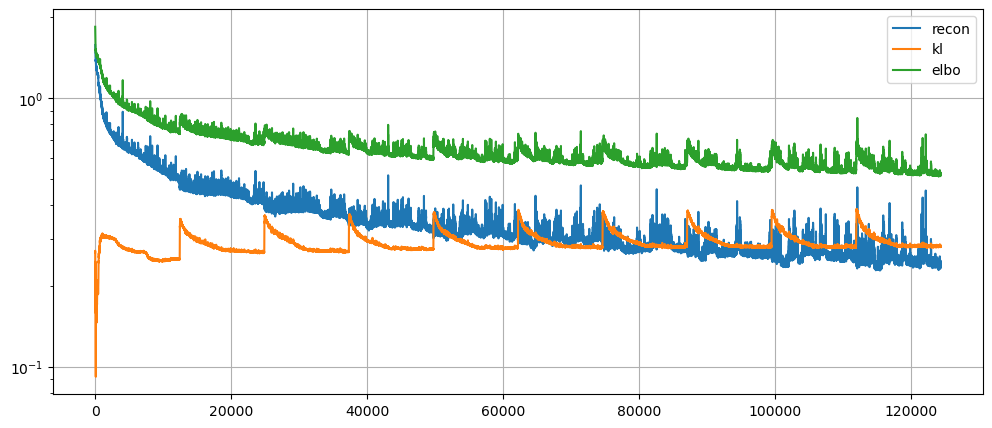

In [11]:
plt.figure(figsize=(12, 5))
plt.loglog(logger["loss_recon"], label="loss_recon")
plt.loglog(logger["loss_kl"], label="loss_kl")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(12, 5))
plt.loglog([kl+nll for kl, nll in zip(logger["loss_kl"], logger["loss_recon"])], label="elbo")
plt.plot(logger["beta"], label="beta")
plt.legend()
plt.grid()
plt.show()